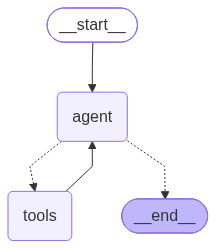

In [17]:
from pathlib import Path
from typing import Annotated, TypedDict, Literal

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

from app.services.llm_service import llm_service
from app.services.file_service import file_service
from app.services.weather_service import weather_service
from app.services.crawler_service import crawler_service
from app.services.tts_service import tts_service
from IPython.display import display
from rich import print as rprint

SYSTEM_PROMPT = (
    "你是桌面宠物「小桌」的智能体大脑，性格活泼友好。"
    "你可以调用工具帮用户完成任务：查天气、爬取网页、读写本地文件、用语音说话。"
    "用户的问题需要外部信息或操作时，主动调用对应工具，不要凭空编造答案。"
    "回复保持简洁，适合桌面宠物场景。"
)


# ========== 工具定义（tool calling）==========

@tool
def read_file(path: str) -> str:
    """读取本地文件内容。path 为文件的绝对路径。"""
    return file_service.read_file(path)


@tool
def write_file(path: str, content: str) -> str:
    """创建或修改本地文件。path 为目标文件的绝对路径，content 为要写入的完整内容。"""
    file_service.write_file(path, content)
    return f"文件已写入: {path}"


@tool
def list_dir(path: str) -> str:
    """列出指定目录下的文件和子目录。path 为目录的绝对路径。"""
    return ", ".join(file_service.list_dir(path))


@tool
async def get_weather(location: str) -> str:
    """查询指定城市的实时天气。location 为城市名，如：北京。"""
    result = await weather_service.get_weather(location)
    return str(result)


@tool
async def crawl_web(url: str) -> str:
    """爬取网页内容，返回标题、正文和链接。url 为完整网址，以 http(s):// 开头。"""
    result = await crawler_service.parse_content(url)
    return str(result)


# @tool
# async def speak(text: str) -> str:
#     """用语音朗读一段文字，让桌宠开口说话。text 为要朗读的内容。"""
#     output = TTS_DIR / "last.mp3"
#     await tts_service.synthesize(text, str(output))
#     return "语音已合成"


tools = [read_file, write_file, list_dir, get_weather, crawl_web]
tool_node = ToolNode(tools=tools)


# ========== LangGraph 状态图 ==========

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


async def agent_node(state: AgentState):
    """Agent 节点：LLM 结合工具 schema 决定回复还是调用工具"""
    llm_with_tools = llm_service.llm.bind_tools(tools)
    response = await llm_with_tools.ainvoke(state["messages"])
    return {"messages": [response]}


def should_continue(state: AgentState) -> Literal["tools", END]:
    """条件边：上一步产生了工具调用则进入工具节点，否则结束"""
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        return "tools"
    return END


workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", should_continue, path_map=["tools", END])
workflow.add_edge("tools", "agent")

# MemorySaver：LangGraph checkpointer，让智能体拥有多轮对话记忆
checkpointer = MemorySaver()
pet_agent = workflow.compile(checkpointer=checkpointer)
display(pet_agent)



In [14]:
async def run_agent(user_message: str, session_id: str = "default") -> dict:
    """
    运行桌宠智能体（LangGraph 驱动，自动 tool calling）
    :param user_message: 用户输入
    :param session_id: 会话 ID（用于多轮记忆隔离）
    :return: reply 最终回复 / audio_url 语音地址 / tool_calls 本次调用的工具列表
    """
    result = await pet_agent.ainvoke(
        {
            "messages": [
                SystemMessage(content=SYSTEM_PROMPT),
                HumanMessage(content=user_message),
            ]
        },
        config={"configurable": {"thread_id": session_id}},
    )

    messages = result["messages"]
    reply = messages[-1].content

    # 收集本次运行的工具调用情况
    audio_url = None
    used_tools = []
    for msg in messages:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                used_tools.append(tc["name"])
                if tc["name"] == "speak":
                    audio_url = "/static/tts/last.mp3"

    return {"reply": reply, "audio_url": audio_url, "tool_calls": used_tools}
